In [2]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
#%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

In [3]:
N = 50

In [4]:
data = norm.rvs(1, 0.2, size = N)

In [5]:
data

array([1.04606087, 1.07343823, 1.06799295, 1.19714234, 0.97918205,
       0.75390088, 1.0028281 , 0.96458386, 0.70537595, 1.12509863,
       0.80228003, 0.96886506, 1.23070757, 1.03704173, 1.35302429,
       1.06990015, 0.99994004, 0.78763397, 0.70949523, 0.85672461,
       0.99392021, 1.00182074, 0.89962357, 1.3088177 , 1.22219368,
       1.32004241, 0.86268463, 0.65961022, 0.9935622 , 0.90131606,
       1.07029588, 0.90092004, 1.00495902, 1.02777027, 1.2442765 ,
       0.96448936, 0.7984927 , 0.71598992, 1.25827108, 1.13765152,
       1.13046686, 1.06393597, 0.97427756, 0.89207056, 0.88511544,
       1.02324875, 1.17926304, 0.98016448, 0.73134439, 0.95880908])

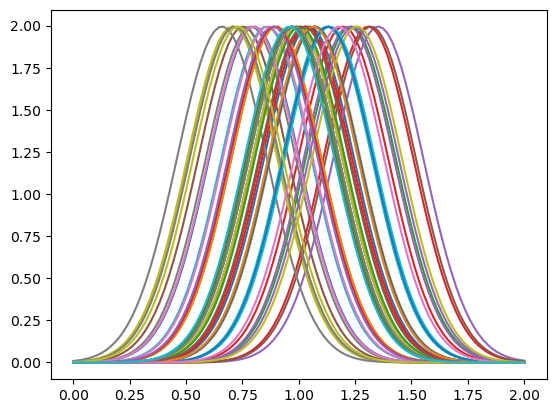

In [6]:
x = np.linspace(0,2,100)

for i in range(N):
    gauss = norm(data[i],0.2)
    plt.plot(x, gauss.pdf(x))

In [7]:
pdfs = []
for i in range(N):
    gauss = norm(data[i],0.2)
    pdfs.append(gauss.pdf(x))

In [8]:
pdfs = np.array(pdfs)

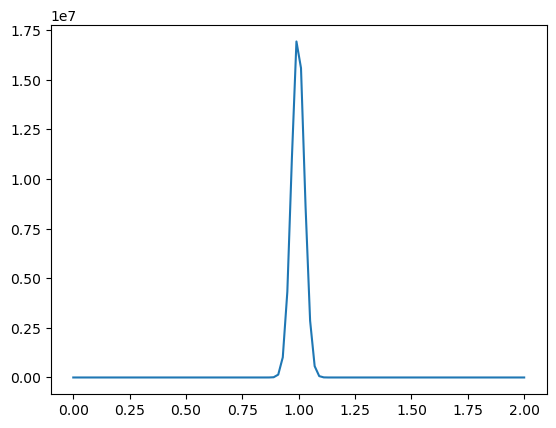

In [9]:
g = 1
for i in range(N):
    gauss = norm(data[i],0.2)
    #plt.plot(x, gauss.pdf(x))
    g = g*gauss.pdf(x)

plt.plot(x, g)

In [10]:
maxlike_indx = np.argmax(g)

In [11]:
mu = x[maxlike_indx]
mu

np.float64(0.98989898989899)

In [12]:
mle = np.mean(data)
mle

np.float64(0.9967324077137991)

In [13]:
err = np.std(data)/np.sqrt(N)
err

np.float64(0.023900815385996962)

In [14]:
loglike = np.log(g)

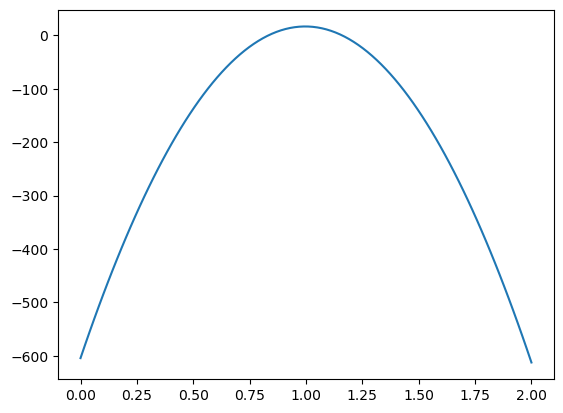

In [15]:
plt.plot(x, loglike)

In [17]:
dtheta = x[1]-x[0]

In [22]:
sigma_f = np.diff(loglike, 2)/dtheta**2
sigma_f *= -1
sigma_f = 1/np.sqrt(sigma_f)[maxlike_indx]

sigma_f

np.float64(0.028284271247461808)

In [23]:
print('Errore Fisher:', sigma_f)
print('Errore teorico:', err)

Errore Fisher: 0.028284271247461808
Errore teorico: 0.023900815385996962


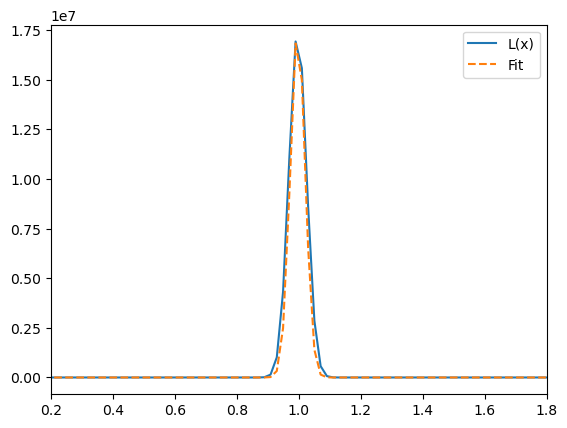

In [41]:
fit = norm.pdf(x, mle, err)

plt.plot(x, g, label='L(x)')

C = 1.05e6
plt.plot(x, C*fit, ls='dashed', label='Fit')

plt.xlim(0.2,1.8)

plt.legend();

### Part 3

In [42]:
sigma_i = np.random.normal(0.2, 0.05, size=N)

In [43]:
sigma_i = np.abs(sigma_i)

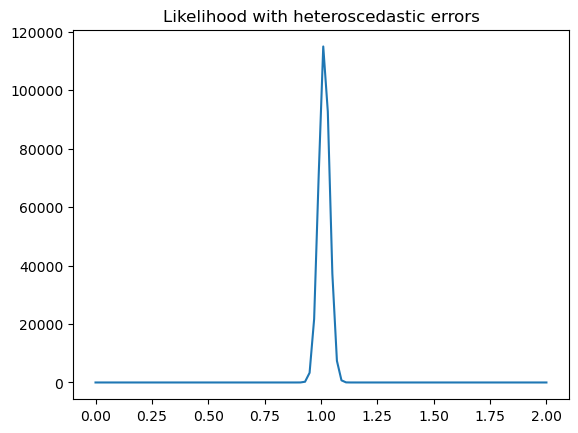

In [44]:
g_hetero = 1

for i in range(N):
    gauss = norm(data[i], sigma_i[i])
    g_hetero *= gauss.pdf(x)

plt.plot(x, g_hetero)
plt.title('Likelihood with heteroscedastic errors')
plt.show()

In [45]:
weights = 1/sigma_i**2
mu_w = np.sum(data*weights)/np.sum(weights)
mu_w

np.float64(1.013982848182996)

In [47]:
sigma_mu = np.sqrt(1/np.sum(weights))
sigma_mu

np.float64(0.024168335320408317)